# Phase 1: BBH Baseline — 复现 GWData-Bootcamp 的 BBH 信号搜寻 baseline（含 Loss 曲线）

本 notebook 对应 README 中的 **Phase 1 (Baseline)**：复现 GWData-Bootcamp 的 BBH（双黑洞）信号搜寻 baseline，使用原版 CNN 模型，验证整条数据管线可用。

本项目的任务是：给定一段 LIGO 探测器的时间序列数据，判断其中**是否包含致密双星旋近阶段的引力波信号**。这是一个二分类问题——信号 vs 纯噪声。

**注意**：这里做的是 detection（有没有信号），不是 classification（区分 BBH 和 BNS）。Phase 1 的目标是先在 BBH 数据上跑通完整训练、评估与 ROC 流程。

**数据来源**：在线模拟生成（参数采样 → 波形模板生成 → 探测器响应 → SNR 归一化 → 噪声叠加 → 白化）  
**模型**：GWData-Bootcamp 原版 8 层 CNN（MyNet）  
**输入形状**：`(batch, 1, 2, 16384)`  
**训练 SNR**：20

## 1. 环境准备

In [1]:
import sys, os
import numpy as np
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.9.1+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [3]:
# 确保 GWData-Bootcamp baseline 代码可用
# 方式一: 当前目录下有 main.py, data_prep_bbh.py, utils.py (从 baseline 复制)
# 方式二: clone 仓库到 GWData-Bootcamp-main/
#   git clone https://github.com/iphysresearch/GWData-Bootcamp.git GWData-Bootcamp-main

# 尝试导入
try:
    from main import MyNet
    from data_prep_bbh import sim_data
    print("✓ Baseline 代码导入成功 (当前目录)")
except ModuleNotFoundError:
    from pathlib import Path
    baseline_dir = Path('.') / 'GWData-Bootcamp-main' / '2023' / 'deep_learning' / 'baseline'
    sys.path.insert(0, str(baseline_dir))
    from main import MyNet
    from data_prep_bbh import sim_data
    print(f"✓ Baseline 代码导入成功 (从 {baseline_dir})")

✓ Baseline 代码导入成功 (当前目录)


## 2. 训练 BBH Baseline

使用 `train_gw_search.py` 的 baseline phase。  
如果已经训练过，可以直接跳到第 3 步加载模型。



In [4]:
# 如果要在 notebook 中直接训练 (较慢, 建议用命令行):
!python train_gw_search.py --phase baseline --epochs 100 --pool_size 5000

# 这里直接复用 train_gw_search.py 的加载逻辑，和脚本保持一致

Using device: cuda
Phase 1: BBH baseline (原版 CNN)
GPU available? True
Pre-generating 5000 samples (BBH, SNR=20.0)...
Done. 5000 samples in 29.5s (169 samples/s)
Pool in memory: (5000, 1, 2, 16384), 625 MB
GPU available? True
Pre-generating 1000 samples (BBH, SNR=20.0)...
Done. 1000 samples in 5.1s (196 samples/s)
Pool in memory: (1000, 1, 2, 16384), 125 MB
Init new network!
MyNet params: 1,457,946
Epoch   1/100 | train_loss=13.6456 test_loss=11.5495 | train_acc=0.490 test_acc=0.510 | lr=0.002999
Epoch  10/100 | train_loss=0.6851 test_loss=50.4742 | train_acc=0.560 test_acc=0.510 | lr=0.002927
Epoch  20/100 | train_loss=0.1930 test_loss=0.9382 | train_acc=0.910 test_acc=0.750 | lr=0.002714
Epoch  30/100 | train_loss=0.0657 test_loss=0.3649 | train_acc=0.940 test_acc=0.870 | lr=0.002382
Epoch  40/100 | train_loss=0.0643 test_loss=0.0021 | train_acc=0.920 test_acc=1.000 | lr=0.001964
Epoch  50/100 | train_loss=0.0490 test_loss=0.0189 | train_acc=0.980 test_acc=1.000 | lr=0.001500
Epoch  6

In [5]:
from pathlib import Path
from train_gw_search import load_model

checkpoint_dir = './checkpoints_baseline/'
expected_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
last_model = next(Path(checkpoint_dir).glob('last_model*.pt'), None)

if last_model is None:
    print('未找到 final checkpoint；当前目录若只有旧版 best checkpoint，需要用更新后的脚本重新训练一次，才能展示完整 100 epoch 结果。')

net, epoch, history = load_model(checkpoint_dir, MyNet, prefer='last')
net.to(device)
net.eval()
print(f"加载到的 epoch: {epoch}")
print(f"模型参数量: {sum(p.numel() for p in net.parameters()):,}")
print(f"训练历史长度: {len(history)}")
if history and len(history) != expected_epochs:
    print(f"注意: 当前 history 长度为 {len(history)}，不是期望的 {expected_epochs}。这说明现有 checkpoint 是旧版保存格式，请重新运行 baseline 训练命令生成 final checkpoint。")

Loaded model from checkpoints_baseline/last_model_e100.pt, epoch=100
加载到的 epoch: 100
模型参数量: 1,457,946
训练历史长度: 100


## 3. Loss 曲线

这里先展示 baseline 训练过程中保存的 train/test loss 与 accuracy 曲线，再在下一节展示 ROC。

显示 loss 图: checkpoints_baseline/loss_history_bbh_cnn.png


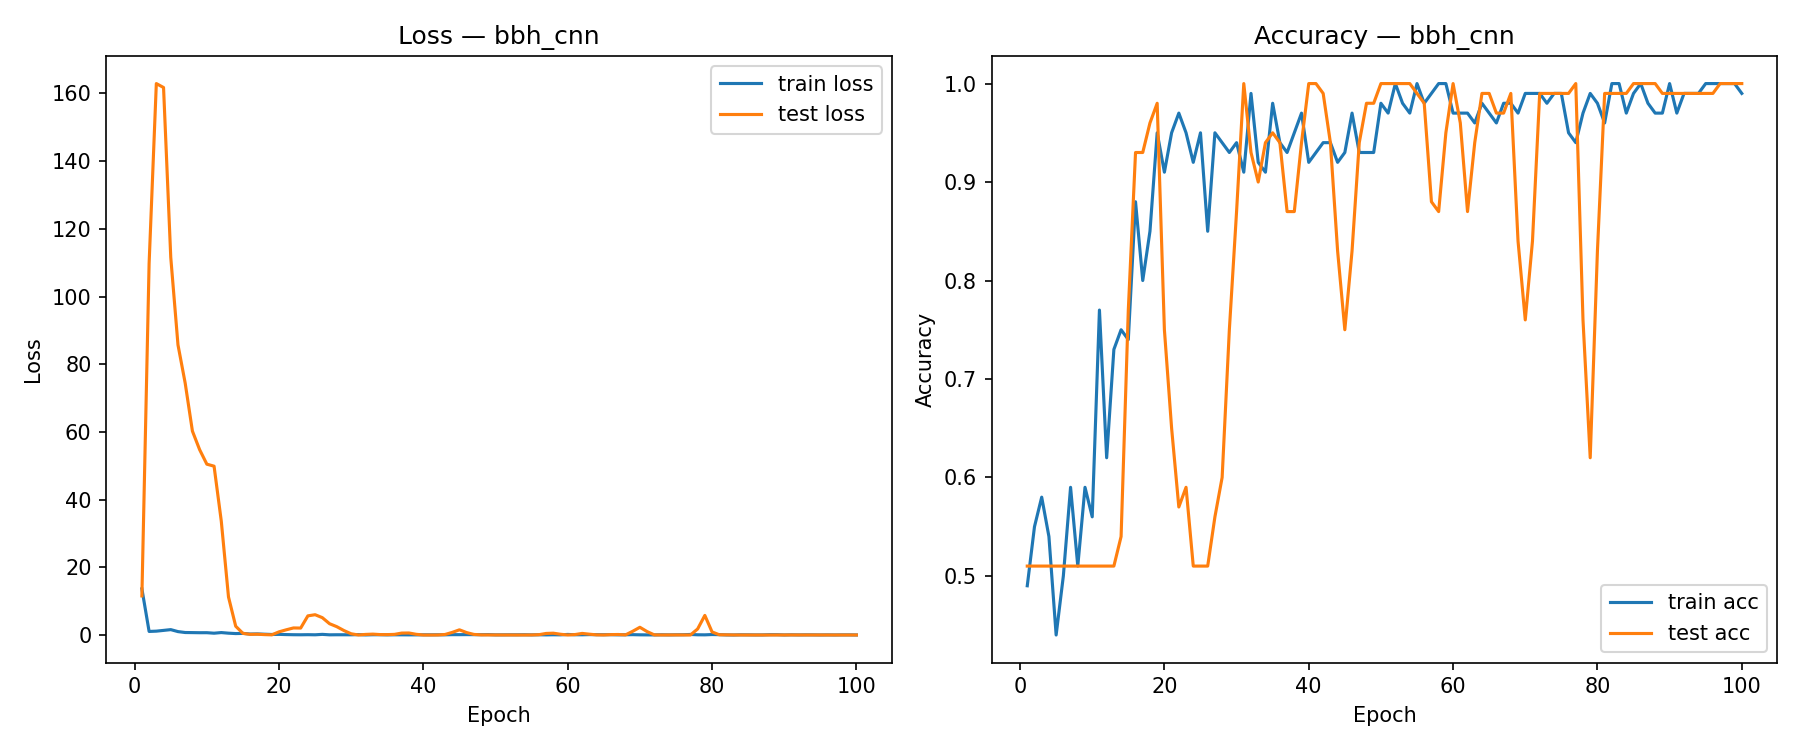

In [6]:
%matplotlib inline
from IPython.display import Image, display
from train_gw_search import plot_loss_history

loss_path = Path(checkpoint_dir) / 'loss_history_bbh_cnn.png'
if history and not loss_path.exists():
    plot_loss_history(history, checkpoint_dir, label='bbh_cnn')

if loss_path.exists():
    print(f'显示 loss 图: {loss_path}')
    display(Image(filename=str(loss_path)))
else:
    print('loss 图未找到。请先运行训练单元，或确认 checkpoints_baseline/loss_history_bbh_cnn.png 已生成。')

## 4. ROC 曲线评估与结果

在上一节 loss 图之后，这里对 SNR = 5, 10, 15, 20 各生成 1000 个测试样本，计算 ROC 和 AUC。

本 notebook 直接复用 `train_gw_search.py` 中的评估与绘图函数，因此这里展示的 ROC 图与正式脚本保持一致。

如果重新运行训练或重新生成评估数据，曲线细节和 AUC 会有轻微随机波动，因此应以当前生成的 `checkpoints_baseline/roc_bbh.png` 为准。

**Baseline 跑通验证完成。**

Evaluating SNRs: 100%|██████████| 4/4 [02:16<00:00, 34.01s/it]


ROC plot saved to checkpoints_baseline/roc_bbh.png


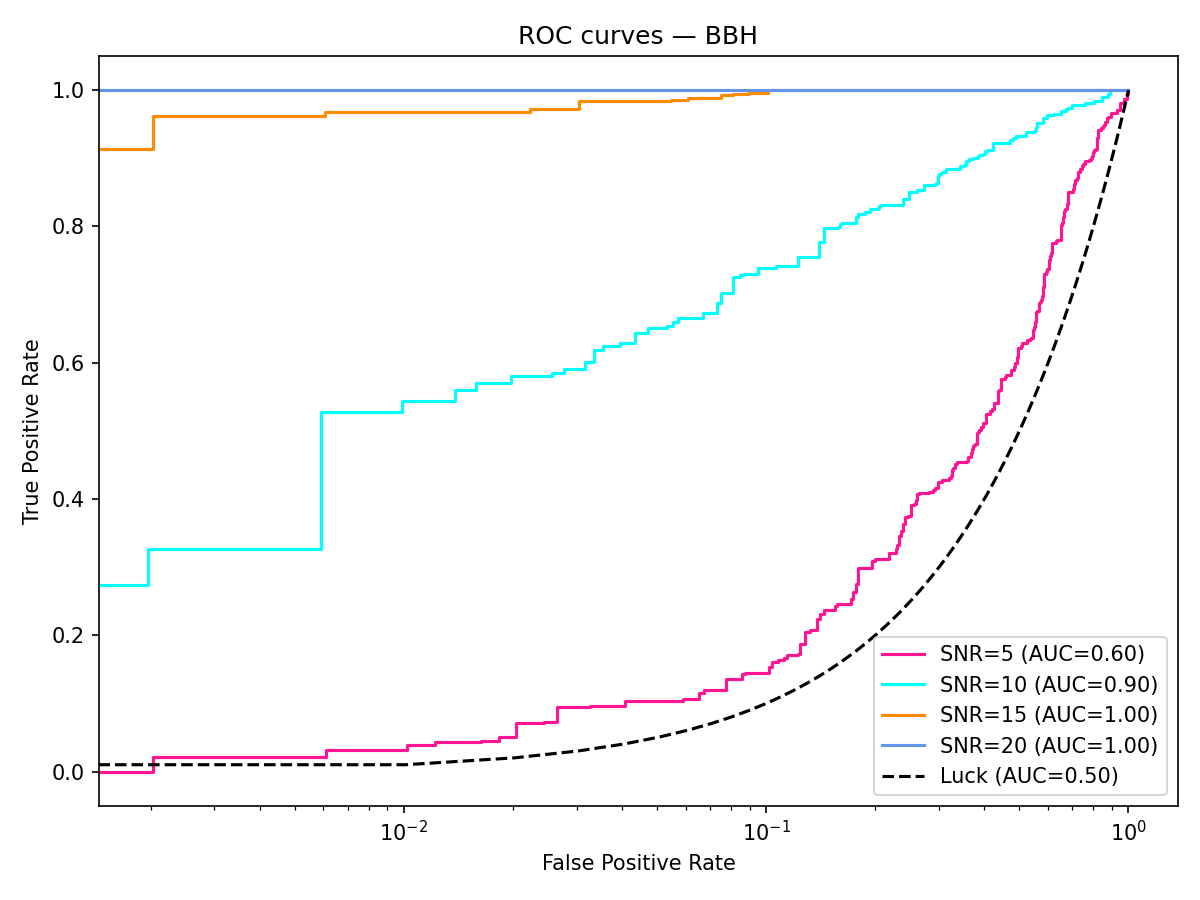

In [7]:
%matplotlib inline
from IPython.display import Image, display
from train_gw_search import plot_roc

plot_roc(net, source='bbh', reshape_for_resnet=False, device=device, outdir=checkpoint_dir)

roc_path = Path(checkpoint_dir) / 'roc_bbh.png'
if roc_path.exists():
    display(Image(filename=str(roc_path)))
else:
    print('ROC 图未找到, 请先运行训练和评估')